# Difficulty vs. Thinking Token Variance

**Question**: Do harder (low-accuracy) queries have higher thinking token variance?

We define query difficulty as the fraction of models (out of 10) that answer incorrectly.
We measure within-query variance using CV (coefficient of variation) of thinking tokens across 6 runs (1 original + 5 repeated).

In [1]:
import json, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.figsize': (10, 6),
})

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'analysis' else os.getcwd()
DATA = os.path.join(BASE, 'data')
print('Data dir:', DATA)

Data dir: /Users/lingjiao/Documents/Research/ThinkingTax/data


## 1. Compute Per-Query Difficulty (across all 10 models)

In [2]:
# Load scores from all 10 AIME models
aime_files = [f for f in os.listdir(os.path.join(DATA, 'consolidated')) if f.startswith('aime-hybrid-')]
print(f'Found {len(aime_files)} AIME model files')

# Collect per-query scores: {index: [score_model1, score_model2, ...]}
query_scores = {}
model_names = []
for f in sorted(aime_files):
    model_name = f.replace('aime-hybrid-', '').replace('.json', '')
    model_names.append(model_name)
    with open(os.path.join(DATA, 'consolidated', f)) as fh:
        records = json.load(fh)['records']
    for r in records:
        idx = r['index']
        if idx not in query_scores:
            query_scores[idx] = []
        query_scores[idx].append(r['score'])

# Compute difficulty = 1 - accuracy (fraction incorrect)
difficulty = {}
for idx, scores in query_scores.items():
    difficulty[idx] = 1.0 - np.mean(scores)

print(f'\nQueries: {len(difficulty)}')
print(f'Models: {len(model_names)}: {model_names}')
print(f'Difficulty range: [{min(difficulty.values()):.2f}, {max(difficulty.values()):.2f}]')
print(f'Mean difficulty: {np.mean(list(difficulty.values())):.2f}')

# Distribution
diff_vals = sorted(difficulty.values())
for d in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    n = sum(1 for v in diff_vals if abs(v - d) < 0.05)
    if n > 0:
        print(f'  difficulty={d:.1f}: {n} queries')

Found 10 AIME model files

Queries: 60
Models: 10: ['MiniMax-M2.5', 'claude-haiku-4.5', 'claude-opus-4.6-thinking', 'claude-opus-4.6', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview', 'gpt-5-mini', 'gpt-5.2-high', 'gpt-5.2', 'kimi-k2.5']
Difficulty range: [0.00, 0.80]
Mean difficulty: 0.26
  difficulty=0.0: 4 queries
  difficulty=0.1: 17 queries
  difficulty=0.2: 11 queries
  difficulty=0.3: 12 queries
  difficulty=0.4: 7 queries
  difficulty=0.5: 5 queries
  difficulty=0.6: 2 queries
  difficulty=0.7: 1 queries
  difficulty=0.8: 1 queries


## 2. Compute Per-Query Thinking Token Variance (from repeated trials)

In [3]:
# For each of our 3 repeated-trial models, compute per-query CV
rt_models = {
    'gpt-5.2-high': 'GPT-5.2',
    'gpt-5-mini': 'GPT-5 Mini',
    'gemini-3-flash-preview': 'Gemini 3 Flash',
}

rows = []
for model_key, label in rt_models.items():
    # Load original
    with open(os.path.join(DATA, 'consolidated', f'aime-hybrid-{model_key}.json')) as f:
        orig = {r['index']: r for r in json.load(f)['records']}
    
    # Load repeated trials
    runs_by_idx = []
    for ri in range(5):
        fp = os.path.join(DATA, 'repeated_trial', 'aime', model_key, f'run{ri}.json')
        with open(fp) as f:
            runs_by_idx.append({r['index']: r for r in json.load(f)['records']})
    
    # Common indices
    common = set(orig.keys())
    for run in runs_by_idx:
        common &= set(run.keys())
    
    for idx in sorted(common):
        orig_tt = orig[idx]['thinking_tokens']
        trial_tts = [run[idx]['thinking_tokens'] for run in runs_by_idx]
        all_tts = [orig_tt] + trial_tts
        mean_tt = np.mean(all_tts)
        if mean_tt > 0:
            cv = np.std(all_tts) / mean_tt
            max_min = max(all_tts) / max(min(all_tts), 1)
        else:
            cv = 0
            max_min = 1
        rows.append({
            'index': idx,
            'model': label,
            'model_key': model_key,
            'difficulty': difficulty.get(idx, np.nan),
            'cv': cv,
            'max_min_ratio': max_min,
            'mean_tt': mean_tt,
            'std_tt': np.std(all_tts),
            'orig_score': orig[idx].get('score', np.nan),
        })

df = pd.DataFrame(rows)
print(f'Total data points: {len(df)}')
print(f'\nPer-model counts:')
print(df.groupby('model')['index'].count())
df.head(10)

Total data points: 177

Per-model counts:
model
GPT-5 Mini        60
GPT-5.2           57
Gemini 3 Flash    60
Name: index, dtype: int64


,index,model,model_key,difficulty,cv,max_min_ratio,mean_tt,std_tt,orig_score
0,1,GPT-5.2,gpt-5.2-high,0.1,0.174542,1.657787,595.000000,103.852459,1.0
1,2,GPT-5.2,gpt-5.2-high,0.2,0.428962,3.185226,3169.000000,1359.379025,1.0
2,3,GPT-5.2,gpt-5.2-high,0.1,0.318903,2.282178,279.666667,89.186446,1.0
3,4,GPT-5.2,gpt-5.2-high,0.1,0.163192,1.639939,818.500000,133.572390,1.0
4,5,GPT-5.2,gpt-5.2-high,0.4,0.236898,2.100514,3887.666667,920.978586,1.0
5,7,GPT-5.2,gpt-5.2-high,0.5,0.356390,2.683678,6475.500000,2307.806011,1.0
6,8,GPT-5.2,gpt-5.2-high,0.3,0.156426,1.622144,2174.500000,340.147395,1.0
7,9,GPT-5.2,gpt-5.2-high,0.1,0.174369,1.754297,1398.833333,243.912837,1.0
8,10,GPT-5.2,gpt-5.2-high,0.1,0.190189,1.734797,746.833333,142.039216,1.0
9,11,GPT-5.2,gpt-5.2-high,0.1,0.174228,1.641929,723.500000,126.053891,1.0


## 3. Scatter: Difficulty vs. CV

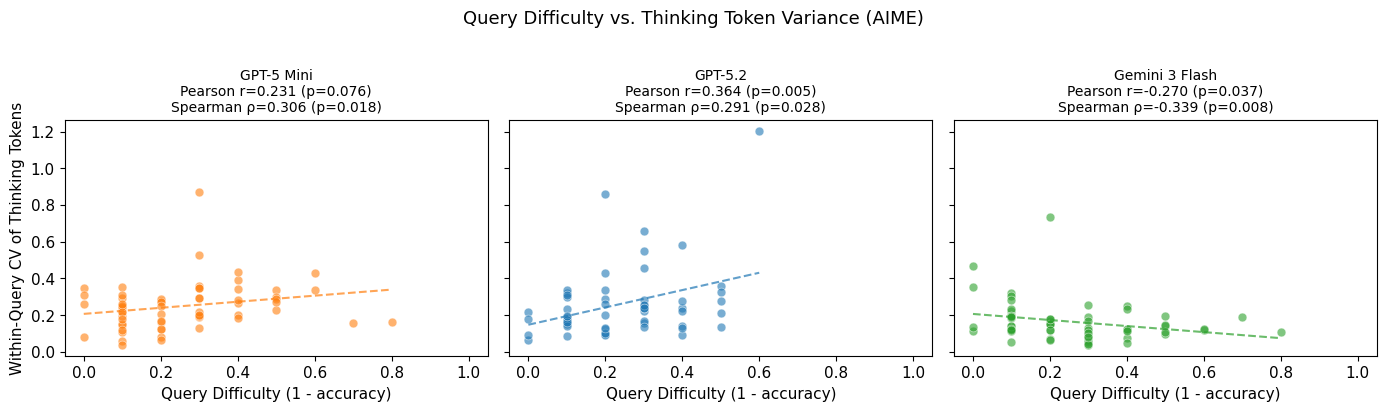

In [4]:
colors = {'GPT-5.2': '#1f77b4', 'GPT-5 Mini': '#ff7f0e', 'Gemini 3 Flash': '#2ca02c'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (model, grp) in zip(axes, df.groupby('model')):
    ax.scatter(grp['difficulty'], grp['cv'], 
               color=colors[model], alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
    
    # Correlation
    r, p = stats.pearsonr(grp['difficulty'], grp['cv'])
    rho, p_s = stats.spearmanr(grp['difficulty'], grp['cv'])
    
    # Trend line
    z = np.polyfit(grp['difficulty'], grp['cv'], 1)
    x_line = np.linspace(grp['difficulty'].min(), grp['difficulty'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), '--', color=colors[model], alpha=0.7, linewidth=1.5)
    
    ax.set_title(f'{model}\nPearson r={r:.3f} (p={p:.3f})\nSpearman ρ={rho:.3f} (p={p_s:.3f})', fontsize=10)
    ax.set_xlabel('Query Difficulty (1 - accuracy)')
    ax.set_xlim(-0.05, 1.05)

axes[0].set_ylabel('Within-Query CV of Thinking Tokens')
plt.suptitle('Query Difficulty vs. Thinking Token Variance (AIME)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Grouped Analysis: Easy vs. Medium vs. Hard

                                      n_queries  mean_cv  median_cv  mean_max_min    mean_tt
model          diff_group                                                                   
GPT-5 Mini     Easy (≤30% incorrect)         32    0.200      0.212         1.849   1910.661
               Hard (>70% incorrect)          1    0.165      0.165         1.520  17708.333
               Medium (30-70%)               27    0.311      0.292         2.640   7716.457
GPT-5.2        Easy (≤30% incorrect)         32    0.216      0.174         1.981   1567.771
               Medium (30-70%)               25    0.313      0.237         3.121   6082.707
Gemini 3 Flash Easy (≤30% incorrect)         32    0.197      0.159         1.819  11345.323
               Hard (>70% incorrect)          1    0.108      0.108         1.451  37392.833
               Medium (30-70%)               27    0.127      0.119         1.458  21156.796



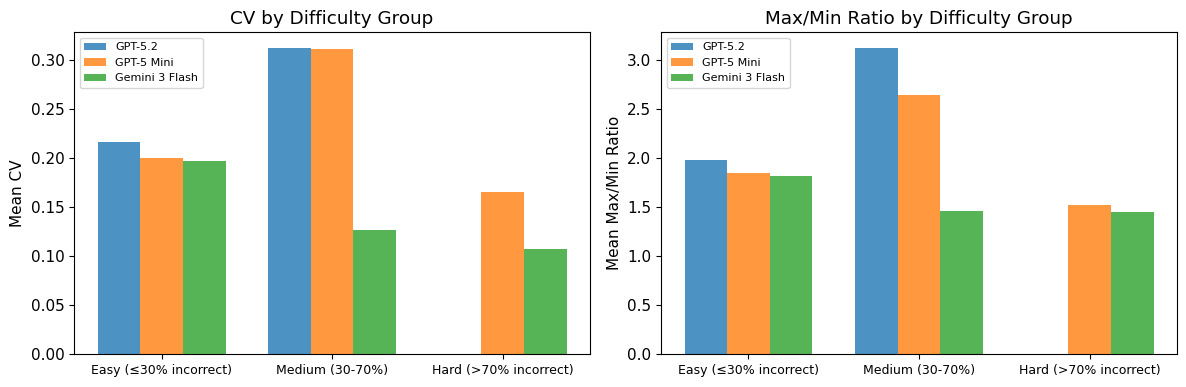

In [5]:
# Bin queries into difficulty groups
def difficulty_group(d):
    if d <= 0.3:
        return 'Easy (≤30% incorrect)'
    elif d <= 0.7:
        return 'Medium (30-70%)'
    else:
        return 'Hard (>70% incorrect)'

df['diff_group'] = df['difficulty'].apply(difficulty_group)

# Summary table
summary = df.groupby(['model', 'diff_group']).agg(
    n_queries=('index', 'count'),
    mean_cv=('cv', 'mean'),
    median_cv=('cv', 'median'),
    mean_max_min=('max_min_ratio', 'mean'),
    mean_tt=('mean_tt', 'mean'),
).round(3)

print(summary.to_string())
print()

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

groups = ['Easy (≤30% incorrect)', 'Medium (30-70%)', 'Hard (>70% incorrect)']
model_list = ['GPT-5.2', 'GPT-5 Mini', 'Gemini 3 Flash']
x = np.arange(len(groups))
width = 0.25

for i, model in enumerate(model_list):
    sub = df[df['model'] == model]
    cvs = [sub[sub['diff_group'] == g]['cv'].mean() for g in groups]
    mmr = [sub[sub['diff_group'] == g]['max_min_ratio'].mean() for g in groups]
    axes[0].bar(x + i * width, cvs, width, label=model, color=colors[model], alpha=0.8)
    axes[1].bar(x + i * width, mmr, width, label=model, color=colors[model], alpha=0.8)

for ax, ylabel, title in zip(axes, 
    ['Mean CV', 'Mean Max/Min Ratio'],
    ['CV by Difficulty Group', 'Max/Min Ratio by Difficulty Group']):
    ax.set_xticks(x + width)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Aggregated Correlation (pooling all models)

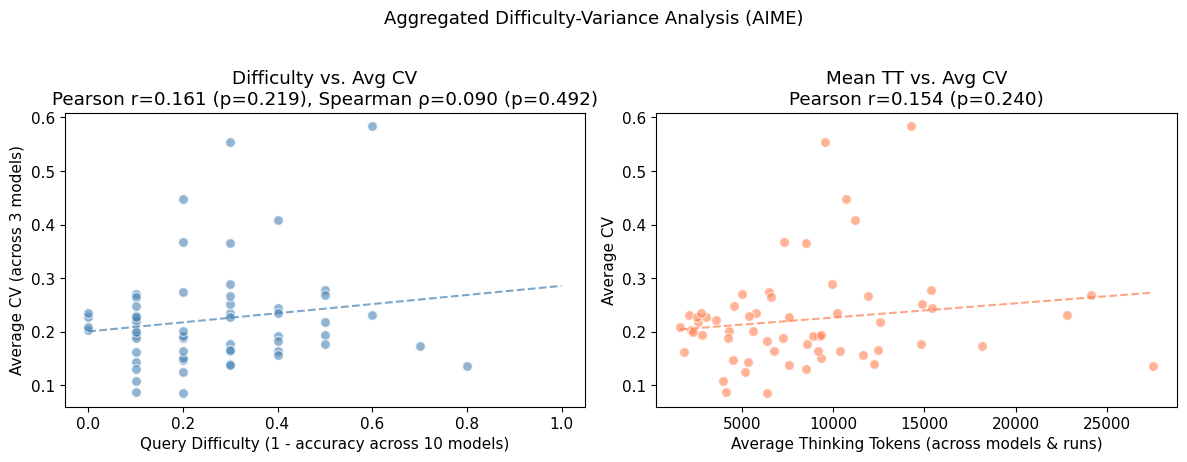

In [6]:
# Per-query difficulty vs average CV across models
query_avg = df.groupby('index').agg(
    difficulty=('difficulty', 'first'),
    avg_cv=('cv', 'mean'),
    avg_max_min=('max_min_ratio', 'mean'),
    avg_mean_tt=('mean_tt', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# CV vs difficulty
ax = axes[0]
ax.scatter(query_avg['difficulty'], query_avg['avg_cv'], s=50, alpha=0.6, color='steelblue', edgecolors='white')
r, p = stats.pearsonr(query_avg['difficulty'], query_avg['avg_cv'])
rho, p_s = stats.spearmanr(query_avg['difficulty'], query_avg['avg_cv'])
z = np.polyfit(query_avg['difficulty'], query_avg['avg_cv'], 1)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, np.polyval(z, x_line), '--', color='steelblue', alpha=0.7)
ax.set_xlabel('Query Difficulty (1 - accuracy across 10 models)')
ax.set_ylabel('Average CV (across 3 models)')
ax.set_title(f'Difficulty vs. Avg CV\nPearson r={r:.3f} (p={p:.3f}), Spearman ρ={rho:.3f} (p={p_s:.3f})')

# Mean TT vs CV (does more thinking → more variance?)
ax = axes[1]
ax.scatter(query_avg['avg_mean_tt'], query_avg['avg_cv'], s=50, alpha=0.6, color='coral', edgecolors='white')
r2, p2 = stats.pearsonr(query_avg['avg_mean_tt'], query_avg['avg_cv'])
z2 = np.polyfit(query_avg['avg_mean_tt'], query_avg['avg_cv'], 1)
x_line2 = np.linspace(query_avg['avg_mean_tt'].min(), query_avg['avg_mean_tt'].max(), 100)
ax.plot(x_line2, np.polyval(z2, x_line2), '--', color='coral', alpha=0.7)
ax.set_xlabel('Average Thinking Tokens (across models & runs)')
ax.set_ylabel('Average CV')
ax.set_title(f'Mean TT vs. Avg CV\nPearson r={r2:.3f} (p={p2:.3f})')

plt.suptitle('Aggregated Difficulty-Variance Analysis (AIME)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Statistical Tests

In [7]:
print('='*60)
print('STATISTICAL SUMMARY')
print('='*60)

# Per-model correlations
print('\n--- Per-Model: Difficulty vs CV ---')
for model in ['GPT-5.2', 'GPT-5 Mini', 'Gemini 3 Flash']:
    sub = df[df['model'] == model]
    r, p = stats.pearsonr(sub['difficulty'], sub['cv'])
    rho, p_s = stats.spearmanr(sub['difficulty'], sub['cv'])
    print(f'{model:20s}: Pearson r={r:+.3f} (p={p:.4f}), Spearman ρ={rho:+.3f} (p={p_s:.4f})')

# Aggregated
print('\n--- Aggregated (avg across models per query) ---')
r, p = stats.pearsonr(query_avg['difficulty'], query_avg['avg_cv'])
rho, p_s = stats.spearmanr(query_avg['difficulty'], query_avg['avg_cv'])
print(f'Difficulty vs Avg CV: Pearson r={r:+.3f} (p={p:.4f}), Spearman ρ={rho:+.3f} (p={p_s:.4f})')

# Mann-Whitney: easy vs hard
print('\n--- Mann-Whitney U: Easy vs Hard queries ---')
for model in ['GPT-5.2', 'GPT-5 Mini', 'Gemini 3 Flash']:
    sub = df[df['model'] == model]
    easy = sub[sub['difficulty'] <= 0.3]['cv']
    hard = sub[sub['difficulty'] > 0.7]['cv']
    if len(easy) > 0 and len(hard) > 0:
        u, p_u = stats.mannwhitneyu(easy, hard, alternative='less')
        print(f'{model:20s}: easy CV={easy.mean():.3f} (n={len(easy)}), hard CV={hard.mean():.3f} (n={len(hard)}), '
              f'U={u:.0f}, p={p_u:.4f} (one-sided: easy < hard)')
    else:
        print(f'{model:20s}: insufficient data (easy={len(easy)}, hard={len(hard)})')

print('\n--- Key Takeaway ---')
overall_r, overall_p = stats.pearsonr(query_avg['difficulty'], query_avg['avg_cv'])
if overall_p < 0.05:
    direction = 'positive' if overall_r > 0 else 'negative'
    print(f'Significant {direction} correlation between difficulty and variance (r={overall_r:.3f}, p={overall_p:.4f})')
    print('→ Harder queries DO tend to have higher thinking token variance.')
else:
    print(f'No significant correlation (r={overall_r:.3f}, p={overall_p:.4f})')
    print('→ Difficulty does NOT significantly predict variance.')

STATISTICAL SUMMARY

--- Per-Model: Difficulty vs CV ---
GPT-5.2             : Pearson r=+0.364 (p=0.0053), Spearman ρ=+0.291 (p=0.0283)
GPT-5 Mini          : Pearson r=+0.231 (p=0.0763), Spearman ρ=+0.306 (p=0.0176)
Gemini 3 Flash      : Pearson r=-0.270 (p=0.0372), Spearman ρ=-0.339 (p=0.0081)

--- Aggregated (avg across models per query) ---
Difficulty vs Avg CV: Pearson r=+0.161 (p=0.2192), Spearman ρ=+0.090 (p=0.4923)

--- Mann-Whitney U: Easy vs Hard queries ---
GPT-5.2             : insufficient data (easy=32, hard=0)
GPT-5 Mini          : easy CV=0.200 (n=32), hard CV=0.165 (n=1), U=20, p=0.6364 (one-sided: easy < hard)
Gemini 3 Flash      : easy CV=0.197 (n=32), hard CV=0.108 (n=1), U=29, p=0.9091 (one-sided: easy < hard)

--- Key Takeaway ---
No significant correlation (r=0.161, p=0.2192)
→ Difficulty does NOT significantly predict variance.
